# Analyses and figures from Spatial transcriptomics profiling of histopathological growth patterns in colorectal cancer liver metastases

---

This notebook contain analyses and figures from our paper "Spatial transcriptomics profiling of histopathological growth patterns in colorectal cancer liver metastases"

The goal is to analyze difference in gene expression between histopathological growth patterns observed in colorectal cancer liver metastases. 


## Notebook structure
The notebook is organized into two parts:

1. **Pre-processing/Clustering/Marker genes**  
   This part explains how to reproduce the clusters that were used in the study.

2. **Comparing  between growth patterns**  
   This part contains examples for plotting/visualizing differences between growth patterns and plotting gene matrices etc.


## Download data

The processed data required to run the notebook is not included in this repository due to file size limitations.

The data can be interactively be visualized from:

**➡ [`Online viewer`](https://crclm2.serve.scilifelab.se)**

The data, including images, gene count tables (AnnData), raw transcripts (AnnData) and regions (GeoJSON) can be downloaded from:

**➡ [`Panel 2 data (.tar)`](https://crclm2.serve.scilifelab.se/iss_panel_2.tmap?dl=1)**

**➡ [`Panel 1 data (.tar)`](https://crclm2.serve.scilifelab.se/iss_panel_1.tmap?dl=1)**

After downloading, extract .tar data and place it in a `data/` directory in the repository so that the folder structure looks like:

```
project_root/
│
├── notebooks/
│   └── reproduce_figures.ipynb
│
├── data/
│   ├── files/
│   │   └── prepared_cells_panel_2.h5ad
│   │   └── prepared_reads_panel_2.h5ad
│   │   └── regions_panel_2.json
│   │
│   ├── images/
│   │   └── iss_panel_<SAMPLE ID>.tif
│   │   └── ...
└── README.md
```


## Environment setup

The analysis was performed using Python 3.10. To recreate the environment used in this repository:

1. Create a new Conda environment:

```bash
conda create -n iss_crclm python=3.10
conda activate iss_crclm
```

2. Install the required Python packages:

```bash
pip install -r requirements.txt
```

This will hopefully install all packages used in the notebook and analysis.


# 1 Clustering

## 1.0 Preprocessing


## 1.1 Cluster with many different seeds
We will now cluster the data 100 times (with different seeds).
To speed things up we will use multiprocessing. However, this does not work well in notebooks.
The clustering is therefore ran from the regular Python file `cluster_adata.py`.

## 1.2 Merge results with hierarchial clustering
Once the clustering is done, the next step is to merge the "stable" seed clusterings
into a final parent clustering. A stable seed cluster is defined as a cluster that is repeated
in 75% of the different clusterings. A cluster is defined as repeated if it has a Pearson-correlation
with another cluster above 0.95. 

In [ ]:
import numpy as np
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_cluster_seeds = 100                                # Number of times to run the clustering with different random seeds
min_correlation = 0.95                                  # Cluster centroids with a Pearson correlation above this are considered identical
min_num_trials = round(0.75 * num_cluster_seeds)        # If a cluster appears more than this number of trials, it considered as a good cluster 

# Load the preprocessed data
an = ad.read_h5ad('Preprocessed/adata.h5ad')

seed_clusterings = [np.load(f'Preprocessed/clusters/louvain_cluster_seed{seed}.npy') for seed in range(num_cluster_seeds)]
seed_clusterings = np.array(seed_clusterings, dtype='uint8') # shape: (num_cluster_seeds, n_cells) with cluster labels for each seed

# Compute mean expression profiles for each cluster in each clustering
mean_expressions = {}
for seed_id, clustering in enumerate(seed_clusterings):
    unique_clusters = np.unique(clustering)
    for cluster_id in unique_clusters:
        uid = f"{seed_id}_{cluster_id}"
        mean_expressions[uid] = an.X[clustering == cluster_id].mean(axis=0)

mean_expression_df = pd.DataFrame(mean_expressions, index=an.var_names.values) # shape: (n_genes, num_clusters) with mean expression of each gene in each cluster

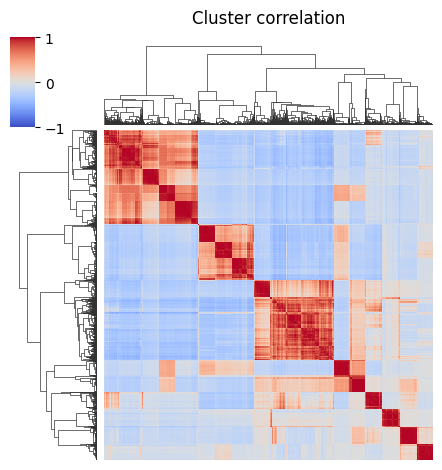

In [ ]:
# Compute the correlation between the mean expression profiles of the clusters across all seed clusterings
correlation = mean_expression_df.corr()
g = sns.clustermap(correlation, row_cluster=True, col_cluster=True, cmap="coolwarm", figsize=(5,5), vmin=-1, vmax=1)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_title('Cluster correlation', y=1.3)
plt.show()


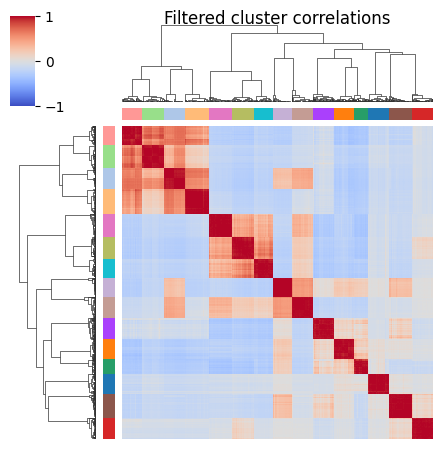

In [ ]:
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from scanpy.plotting.palettes import default_20, default_28, godsnot_102

# Merge clusters that are highly correlated across different seeds
clusters = correlation.index.to_numpy()
corr_values = correlation.to_numpy()

# cluster labels are in format "<seed>_<cluster>"
parts = pd.Series(clusters).str.split("_", expand=True).astype(int)
seeds = parts[0].to_numpy()  # seed id

# Count, for each cluster, how many clusters from OTHER seeds pass correlation threshold
is_similar = corr_values > min_correlation
np.fill_diagonal(is_similar, False)  # ignore self-correlation
is_other_seed = seeds[:, None] != seeds[None, :]

repetition_counts = (is_similar & is_other_seed).sum(axis=1)
num_cluster_repetitions = dict(zip(clusters, repetition_counts.astype(int)))

# Filter out clusters that do not appear in at least min_num_trials seeds
good_cluster_mask = np.array(list(num_cluster_repetitions.values())) > min_num_trials
correlation_filtered = correlation.iloc[good_cluster_mask, :]
correlation_filtered = correlation_filtered.iloc[:, good_cluster_mask]

# Run hierarchical clustering on the filtered correlation matrix and plot the heatmap
distance_matrix = 1.0 - correlation_filtered.values
condensed_distance_matrix = squareform(distance_matrix)
Z = linkage(condensed_distance_matrix, method='single')
clusters_array = fcluster(Z, 0.05, criterion='distance')

# Map each filtered "<seed>_<cluster>" id to its parental "hierarchical" cluster label
map_seed_cluster_to_parent = dict(zip(correlation_filtered.index, clusters_array))

# Re-encode labels to consecutive integers: 0..n_labels-1
unique_labels = np.unique(clusters_array)
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

# Final mapping used below for color assignment
map_seed_cluster_to_parent = {cluster_id: label_to_idx[label] for cluster_id, label in map_seed_cluster_to_parent.items()}

# Create colors
if len(unique_labels) < 20:
    colors = default_20
elif len(unique_labels) <28:
    colors = default_28
else:
    colors = godsnot_102

# Map each cluster to a color
cluster2color = {cluster : colors[val] for cluster, val in map_seed_cluster_to_parent.items()}

row_colors = [cluster2color[cluster] for cluster in correlation_filtered.index]
col_colors = [cluster2color[cluster] for cluster in correlation_filtered.columns]

g = sns.clustermap(correlation_filtered, row_cluster=True, col_cluster=True, cmap="coolwarm", figsize=(5,5), vmin=-1, vmax=1, row_colors=row_colors, col_colors=col_colors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_title('Filtered cluster correlations', y=1.3)
plt.show()



In [ ]:
# Count how often a cell is assigned a cluster that is part of hierarchial cluster label
num_good_clusters = sum(good_cluster_mask)
num_cells = an.n_obs

cell_counts = np.zeros((num_cells, num_good_clusters), dtype=int)
for seed_id in range(num_cluster_seeds):
    clustering = seed_clusterings[seed_id] # shape: (n_cells,) with labels
    for cluster_id in np.unique(clustering):
        uid = f"{seed_id}_{cluster_id}"
        if uid in map_seed_cluster_to_parent:
            good_cluster_idx = map_seed_cluster_to_parent[uid]  # index of the good cluster this corresponds to
            cell_counts[:, good_cluster_idx] += (clustering == cluster_id).astype(int)

# Get final clustering by assigning each cell to the cluster it was assigned to most often
final_clustering = np.argmax(cell_counts, axis=1)
score = np.max(cell_counts, axis=1)
unique_final_clusters = np.unique(final_clustering)
rename_final_cluster = {u : f'Cluster {i+1:02d}' for i,u in enumerate(unique_final_clusters)}
final_clustering_renamed = np.array([rename_final_cluster[cluster] for cluster in final_clustering])

# Add to AnnData object
an.obs['Clusters'] = final_clustering_renamed
an.obs['Clusters'] = an.obs['Clusters'].astype('category')
an = an[score > 0].copy()  # filter out cells that were never assigned to a good cluster
# Write to file
an.write_h5ad('Preprocessed/adata_with_clusters_filter.h5ad')

## 1.3 Marker genes
We will now compute marker genes for each cluster. We will use these to annotate each cluster

In [5]:
import scanpy as sc
import scipy.sparse as sp
import numpy as np
import pandas as pd


def compute_marker_genes(adata: sc.AnnData, cluster_key: str, logfold_cutoff: float = 2.0, pval_cutoff: float = 0.05, frac_cutoff: float = 0.20, use_raw: bool = True):
    """
    Compute marker genes for each cluster using Wilcoxon rank-sum test.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object with raw counts in .raw
    cluster_key : str
        Key in adata.obs containing cluster labels
    logfold_cutoff : float
        Minimum log fold change threshold (default: 2.0)
    pval_cutoff : float
        Maximum adjusted p-value threshold (default: 0.05)
    frac_cutoff : float
        Minimum fraction of cells expressing gene (default: 0.20)
    
    Returns:
    --------
    dict
        Dictionary mapping cluster names to lists of marker gene names
    """
    if use_raw and adata.raw is not None:
        adata_raw = adata.raw.to_adata()
    else:
        adata_raw = adata.copy()
    
    # Run differential expression analysis
    sc.tl.rank_genes_groups(
        adata_raw,
        groupby=cluster_key,
        method="wilcoxon",
        tie_correct=True
    )
    
    rgg_df = sc.get.rank_genes_groups_df(adata_raw, group=None)
    unique_clusters = list(adata_raw.obs[cluster_key].cat.categories)
    
    # Compute fraction of cells expressing each gene per cluster
    X = adata_raw.X
    if sp.issparse(X):
        X_bin = X.copy()
        X_bin.data = (X_bin.data > 0).astype(np.int8)
    else:
        X_bin = (X > 0).astype(np.int8)
    
    # Build lookup dictionaries
    pval_dict = {(str(r.group), str(r.names)): r.pvals_adj for _, r in rgg_df.iterrows()}
    lfc_dict = {(str(r.group), str(r.names)): r.logfoldchanges for _, r in rgg_df.iterrows()}
    frac_dict = {}
    
    var_index = pd.Index(adata_raw.var_names)
    for cluster in unique_clusters:
        mask = (adata_raw.obs[cluster_key] == cluster).values
        if sp.issparse(X_bin):
            pos_counts = X_bin[mask].sum(axis=0).A1
        else:
            pos_counts = X_bin[mask].sum(axis=0)
            if hasattr(pos_counts, "A1"):
                pos_counts = pos_counts.A1
        
        denom = mask.sum()
        genes_for_group = rgg_df.loc[rgg_df["group"] == cluster, "names"].unique()
        gene_idx = var_index.get_indexer(genes_for_group)
        frac_vals = pos_counts[gene_idx] / max(denom, 1)
        
        for gene, frac in zip(genes_for_group, frac_vals):
            frac_dict[(str(cluster), str(gene))] = frac
    
    # Filter genes by criteria for each cluster
    marker_genes = {}
    for cluster in unique_clusters:
        marker_genes[cluster] = []
        genes_for_cluster = rgg_df[rgg_df["group"] == cluster]["names"].unique()
        for gene in genes_for_cluster:
            key = (str(cluster), str(gene))
            pval = pval_dict.get(key, 1.0)
            lfc = lfc_dict.get(key, 0.0)
            frac = frac_dict.get(key, 0.0)
            
            if lfc > logfold_cutoff and pval < pval_cutoff and frac > frac_cutoff:
                marker_genes[cluster].append(gene)
    
    return marker_genes


# Load data and compute marker genes
an = sc.read_h5ad('Preprocessed/adata_with_clusters.h5ad')
marker_genes = compute_marker_genes(an, 'Clusters', logfold_cutoff=2.0, pval_cutoff=0.05, frac_cutoff=0.20)

# Store and save
an.uns['marker_genes'] = marker_genes
an.write_h5ad('Preprocessed/adata_with_clusters_marker_genes_filtered.h5ad')

## 1.4 Plot genes per cluster

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


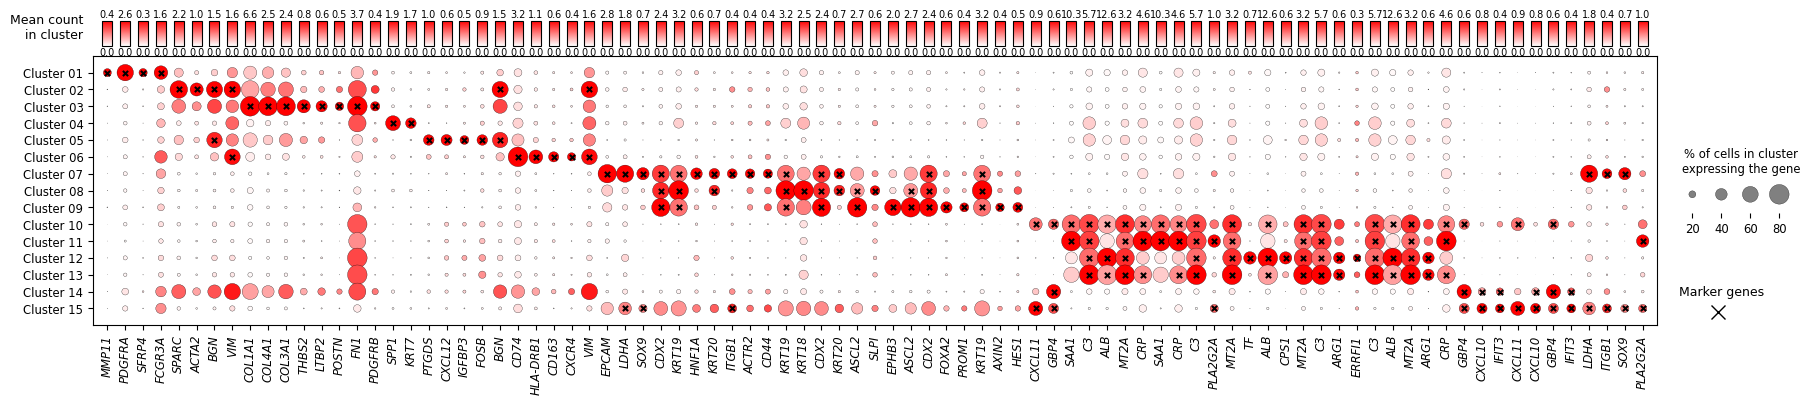

In [2]:

%load_ext autoreload
%autoreload 2
from utils.plotting import custom_dotplot_raw
import scanpy as sc

# Load anndata
ad = sc.read_h5ad('Preprocessed/adata_with_clusters_marker_genes_filtered.h5ad')

custom_dotplot_raw(
    ad,
    cluster_key='Clusters',
    plot_marker_genes=True,
    figsize=(22, 3.5)
)

let's annotate the clusters

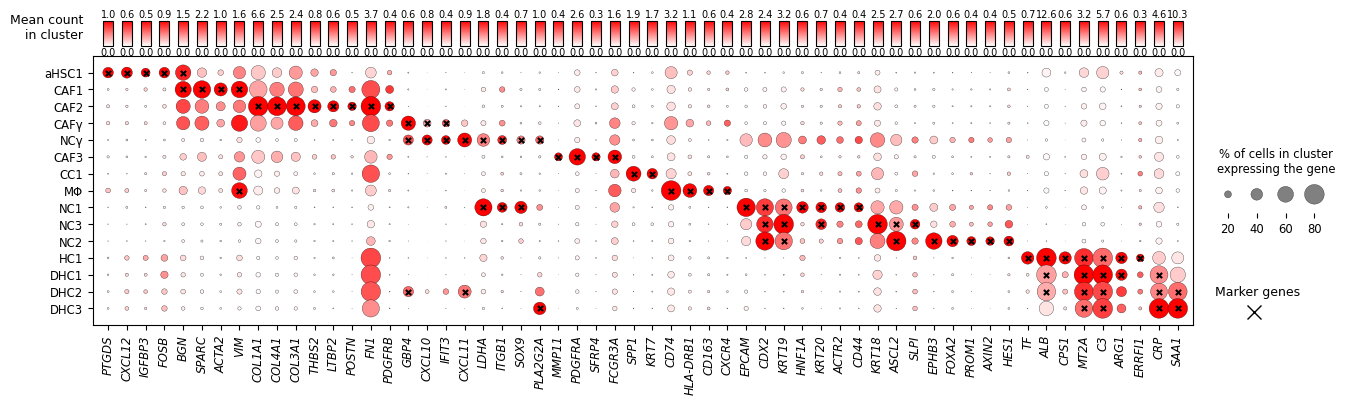

In [15]:
ad = sc.read_h5ad('Preprocessed/adata_with_clusters_marker_genes_filtered.h5ad')

cluster_renamer = {
    'Cluster 01': 'CAF3',   # CAF
    'Cluster 02': 'CAF1',   # CAF
    'Cluster 03': 'CAF2',   # CAF
    'Cluster 04' : 'CC1',   # Cholangiocyte
    'Cluster 05' : 'aHSC1', # Activated hepatic stellate cell
    'Cluster 06' : 'MΦ',    # Macrophage / Immune cell
    'Cluster 07' : 'NC1',   # Neoplastic cell 1
    'Cluster 08' : 'NC3',   # Neoplastic cell 3
    'Cluster 09' : 'NC2',   # Neoplastic cell 2
    'Cluster 10' : 'DHC2',  # Damaged hepatocytes
    'Cluster 11' : 'DHC3',  # Damaged hepatocytes
    'Cluster 12' : 'HC1',   # Healthy hepatocytes
    'Cluster 13' : 'DHC1',  # Damaged hepatocytes
    'Cluster 14' : 'CAFγ',  # CAF interferon-stimulated
    'Cluster 15' : 'NCγ',   # Neoplastic interferon-stimulated
}

ad_new_clusters = ad.copy()

ad_new_clusters.obs['Clusters'] = ad_new_clusters.obs['Clusters'].map(cluster_renamer)
ad_new_clusters.obs['Clusters'] = ad_new_clusters.obs['Clusters'].astype('category')

cluster_order = ['aHSC1', 'CAF1', 'CAF2', 'CAFγ', 'NCγ', 'CAF3', 'CC1', 'MΦ', 'NC1', 'NC3', 'NC2', 'HC1', 'DHC1', 'DHC2', 'DHC3']
ad_new_clusters.obs['Clusters'] = ad_new_clusters.obs['Clusters'].cat.reorder_categories(cluster_order, ordered=True)

new_marker_genes = {cluster_renamer[old_cluster]: genes for old_cluster, genes in ad.uns['marker_genes'].items()}
ad_new_clusters.uns['marker_genes'] = new_marker_genes

custom_dotplot_raw(
    ad_new_clusters,
    cluster_key='Clusters',
    plot_marker_genes=True,
    figsize=(16, 3.5)
)

ad_new_clusters.write_h5ad('Preprocessed/adata_with_renamed_clusters_fitered.h5ad')


# 2 Comparing between growth patterns


## 2.1 Compare cluster proportions between growth patterns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00

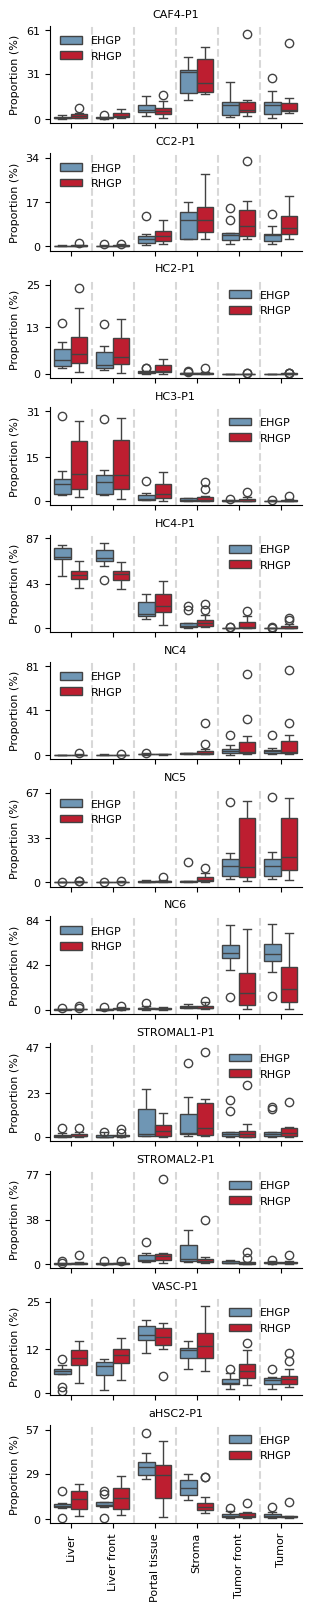

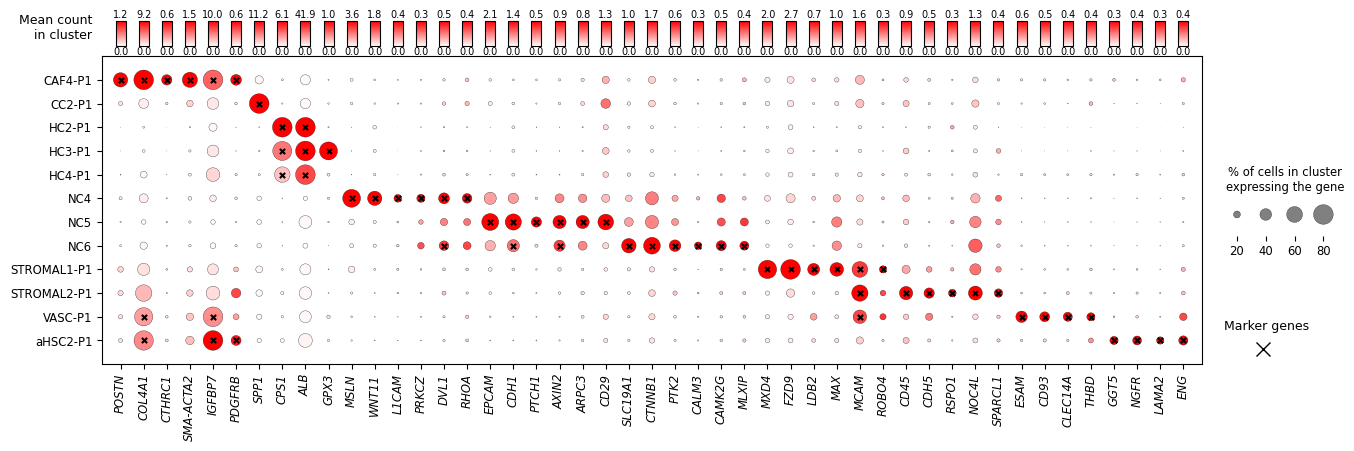

In [10]:

%load_ext autoreload
%autoreload 2
import scanpy as sc
from utils.plotting import plot_cluster_proportions_between_groups, custom_dotplot_raw
panel = 1
ad = sc.read_h5ad(f'prepared_adata/prepared_cells_panel_{panel}.h5ad')
plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    plot_horizontal=False,
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    figsize=(3, 16),
    save=f'svgs/cluster_proportions_panel_{panel}.svg'
)

custom_dotplot_raw(
    ad,
    cluster_key='Clusters',
    plot_marker_genes=True,
    figsize=(16, 4),
    save=f'svgs/dotplot_panel_{panel}.svg'
)


## 2.2 Figure for damaged hepatocytes

c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_mtx from `anndata` i

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Liver front_EHGP vs. Liver front_RHGP: Custom statistical test, P_val:3.210e-02
Liver_EHGP vs. Liver_RHGP: Custom statistical test, P_val:3.210e-02
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Liver front_EHGP vs. Liver front_RHGP: Custom statistical test, P_val:4.202e-02
Portal tissue_EHGP vs. Portal tissue_RHGP: Custom statistical test, P_val:3.210e-02
Tumor front_EHGP vs. Tumor front_RHGP: Custom statistical test, P_val:1.492e-02
Tumor_EHGP vs. Tumor_RHGP: Custom statistical test, P_val:1.492e-02
4.5 1.2000000000000002
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CRP_EHGP vs

,label,region,group,pvalue
0,HC,Liver front,Liver front,0.032097
1,HC,Liver,Liver,0.032097
2,HC,Portal tissue,Portal tissue,0.125091
3,DHC,Liver front,Liver front,0.042023
4,DHC,Liver,Liver,0.062443
5,DHC,Portal tissue,Portal tissue,0.032097
6,DHC,Stroma,Stroma,0.255277
7,DHC,Tumor front,Tumor front,0.014924
8,DHC,Tumor,Tumor,0.014924


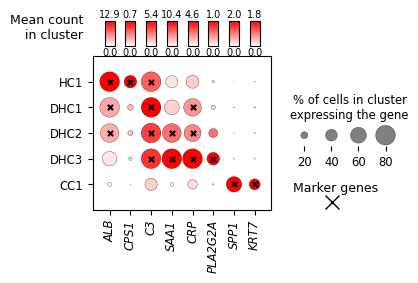

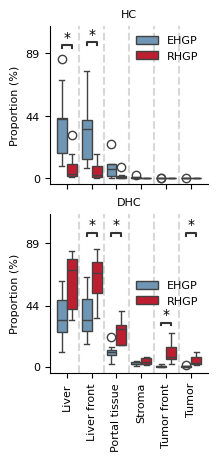

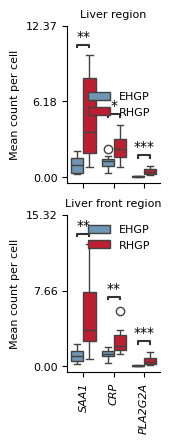

In [1]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
from utils.plotting import custom_dotplot_raw, plot_gene_counts, plot_cluster_proportions_between_groups


ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')


cluster_order = ['HC1', 'DHC1', 'DHC2', 'DHC3', 'CC1']
genes = ['ALB', 'CPS1', 'C3', 'SAA1', 'CRP', 'PLA2G2A', 'SPP1', 'KRT7']

custom_dotplot_raw(
    ad,
    cluster_key='Clusters',
    genes=genes,
    cluster_order=cluster_order,
    figsize=(4, 2),
    plot_marker_genes=True,
    save='svgs/dotplot_hc.svg'
)


# Merge hepatocytes clusters as damaged (SAA1+) and regular.
merge_hc_clusters = {'DHC1' : 'DHC', 'DHC2' : 'DHC', 'DHC3' : 'DHC', 'HC1' : 'HC'}
ad.obs['Clusters HC'] = [merge_hc_clusters.get(c, c) for c in ad.obs['Clusters']]
ad.obs['Clusters HC'] = ad.obs['Clusters HC'].astype('category')

_,_,pval_df = plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters HC',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    clusters_to_plot=['HC', 'DHC'],
    plot_horizontal=False,
    save='svgs/cluster_proportions_hc.svg'
)

plot_gene_counts(
    ad,
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front'],
    genes=['SAA1', 'CRP', 'PLA2G2A'],
    plot_horizontal=False,
    save='svgs/genes_counts_hc.svg'
)

display(pval_df)

## 2.3 Figures for cholangiocytes that are up on RHGP samples

c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_mtx from `anndata` i

p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumor_EHGP vs. Tumor_RHGP: Custom statistical test, P_val:3.740e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KRT7_EHGP vs. KRT7_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:3.734e-02 U_stat=1.900e+01
SPP1_EHGP vs. SPP1_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:4.546e-02 U_stat=2.000e+01


(<Figure size 120x225 with 1 Axes>,
 array([<Axes: title={'center': 'Tumor region'}, ylabel='Mean count per cell'>],
       dtype=object))

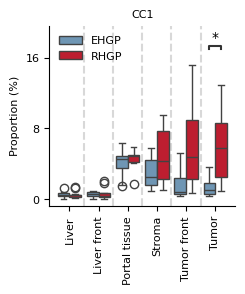

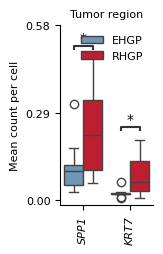

In [1]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
from utils.plotting import plot_gene_counts, plot_cluster_proportions_between_groups

ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')

plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    clusters_to_plot=['CC1'],
    save='svgs/cluster_proportions_cc1.svg',
)

plot_gene_counts(
    ad,
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Tumor'],
    genes=['SPP1', 'KRT7'],
    save='svgs/genes_counts_cc1.svg'
)


## 2.4 Figures for neoplastic cells that are slightly up on RHGP samples

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stroma_EHGP vs. Stroma_RHGP: Custom statistical test, P_val:3.637e-02
Tumor_EHGP vs. Tumor_RHGP: Custom statistical test, P_val:4.216e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GSN_EHGP vs. GSN_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:9.025e-01 U_stat=4.300e+01
KRT18_EHGP vs. KRT18_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:3.049e-02 U_stat=1.800e+01
SLPI_EHGP vs. SLPI_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:5.403e-01 U_stat=3.700e+01


(<Figure size 120x225 with 1 Axes>,
 array([<Axes: title={'center': 'Tumor region'}, ylabel='Mean count per cell'>],
       dtype=object))

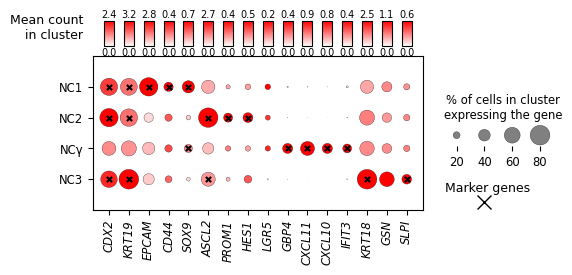

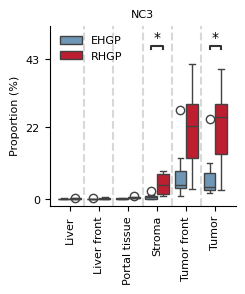

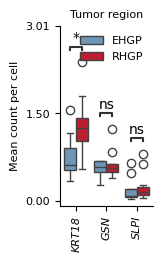

In [10]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
from utils.plotting import custom_dotplot_raw, plot_gene_counts, plot_cluster_proportions_between_groups

ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')
cluster_order = ['NC1', 'NC2', 'NCγ', 'NC3']
genes = ['CDX2', 'KRT19', 'EPCAM', 'CD44', 'SOX9', 'ASCL2', 'PROM1', 'HES1', 'LGR5', 'GBP4', 'CXCL11', 'CXCL10', 'IFIT3', 'KRT18', 'GSN', 'SLPI']

custom_dotplot_raw(
    ad,
    cluster_key='Clusters',
    genes=genes,
    cluster_order=cluster_order,
    figsize=(6, 2),
    plot_marker_genes=True,
    save='svgs/dotplot_nc.svg'
)


plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    clusters_to_plot=['NC3'],
    save='svgs/cluster_proportions_nc.svg'
)

plot_gene_counts(
    ad,
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Tumor'],
    genes=['KRT18', 'GSN', 'SLPI'],
    save='svgs/genes_counts_nc.svg'
)


## 2.5 IFN figures
Here we compare the proportions of interferon-gamma–associated cells and the raw gene counts of interferon-associated genes between growth patterns.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumor front_EHGP vs. Tumor front_RHGP: Custom statistical test, P_val:2.357e-02
Tumor_EHGP vs. Tumor_RHGP: Custom statistical test, P_val:3.740e-02
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stroma_EHGP vs. Stroma_RHGP: Custom statistical test, P_val:1.878e-02
Tumor_EHGP vs. Tumor_RHGP: Custom statistical test, P_val:4.216e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CXCL11_EHGP vs. CXCL11_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:3.749e-03 U_stat=8.100e+01
CXCL10_EHGP vs. CXCL

(<Figure size 480x225 with 3 Axes>,
 array([<Axes: title={'center': 'Tumor region'}, ylabel='Mean count per cell'>,
        <Axes: title={'center': 'Tumor front region'}>,
        <Axes: title={'center': 'Stroma region'}>], dtype=object))

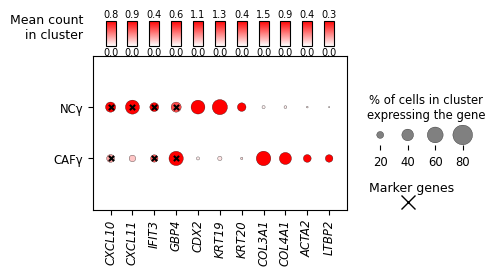

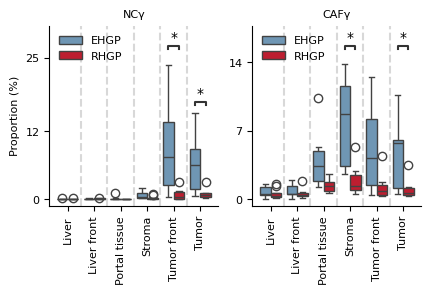

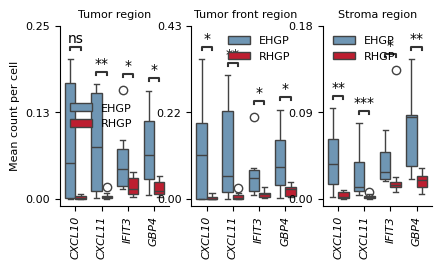

In [9]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
from utils.plotting import custom_dotplot_raw, plot_gene_counts, plot_cluster_proportions_between_groups


ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')


cluster_order = ['NCγ', 'CAFγ']
genes = ['CXCL10', 'CXCL11', 'IFIT3', 'GBP4', 'CDX2', 'KRT19', 'KRT20', 'COL3A1','COL4A1','ACTA2','LTBP2']

custom_dotplot_raw(
    ad,
    cluster_key='Clusters',
    genes=genes,
    cluster_order=cluster_order,
    figsize=(5, 2),
    plot_marker_genes=True,
    save='svgs/dotplot_ifn.svg'
)


plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    clusters_to_plot=cluster_order,
    save='svgs/cluster_proportions_ifn.svg'
)

plot_gene_counts(
    ad,
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Tumor', 'Tumor front', 'Stroma'],
    genes=['CXCL10', 'CXCL11', 'IFIT3', 'GBP4'],
    save='svgs/genes_counts_ifn.svg'
)


In [7]:
import squidpy as sq
import scanpy as sc
import pandas as pd

# Load the anndata object
an = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')
cluster_key = 'Clusters'
unique_clusters = an.obs[cluster_key].cat.categories
records = {}
for region in ['Portal tissue', 'Stroma', 'Tumor']:
    an_by_region = an[an.obs[region], :].copy()
    records[region] = {}
    for scale in [5, 15, 30]:
        print(f"Processing region: {region}, scale: {scale}")
        sq.gr.spatial_neighbors(an_by_region, coord_type='generic', n_neighs=scale, library_key='Sample')
        zscores, _ = sq.gr.nhood_enrichment(an_by_region, cluster_key=cluster_key, n_perms=1000, library_key='Sample', copy=True)
        records[region][f'k = {scale}'] = pd.DataFrame(zscores, columns=unique_clusters, index=unique_clusters)


Processing region: Portal tissue, scale: 5


100%|██████████| 1000/1000 [00:26<00:00, 37.96/s]
c:\Users\axela\anaconda3\envs\omics\lib\site-packages\squidpy\gr\_nhood.py:193: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


Processing region: Portal tissue, scale: 15


100%|██████████| 1000/1000 [00:23<00:00, 41.75/s]
c:\Users\axela\anaconda3\envs\omics\lib\site-packages\squidpy\gr\_nhood.py:193: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


Processing region: Portal tissue, scale: 30


...

100%|██████████| 1000/1000 [00:30<00:00, 32.62/s]


Processing region: Tumor, scale: 15


100%|██████████| 1000/1000 [00:33<00:00, 29.75/s]


Processing region: Tumor, scale: 30


100%|██████████| 1000/1000 [00:35<00:00, 27.78/s]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


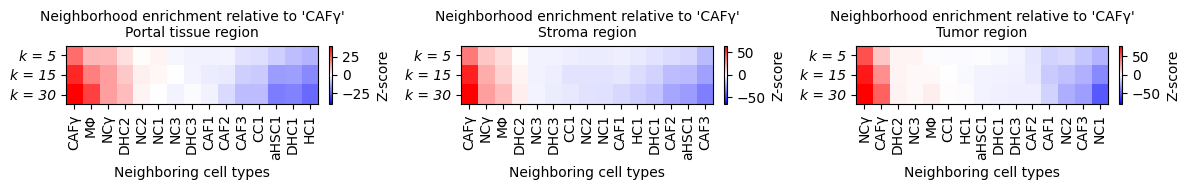

In [8]:
%load_ext autoreload
%autoreload 2
from utils.plotting import plot_nhood_heatmap
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'

fig, axs = plt.subplots(1, 3, figsize=(12, 2))
plot_nhood_heatmap(records['Portal tissue'], focal='CAFγ', ax=axs[0], title="Neighborhood enrichment relative to 'CAFγ'\nPortal tissue region")
plot_nhood_heatmap(records['Stroma'], focal='CAFγ', ax=axs[1], title="Neighborhood enrichment relative to 'CAFγ'\nStroma region")
plot_nhood_heatmap(records['Tumor'], focal='NCγ', ax=axs[2], title="Neighborhood enrichment relative to 'CAFγ'\nTumor region")
fig.savefig('svgs/nhood_ifn.svg')

## 2.6 Cytotoxic cells 
Here we compare proportions cytotoxic cells between growth patterns as well as raw reads counts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stroma_EHGP vs. Stroma_RHGP: Custom statistical test, P_val:4.623e-02
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

All regions_EHGP vs. All regions_RHGP: Custom statistical test, P_val:1.011e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CD8A_EHGP vs. CD8A_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:6.233e-03 U_stat=7.900e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.

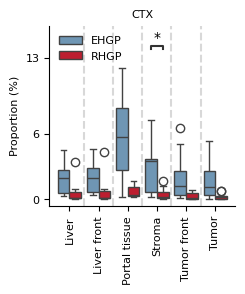

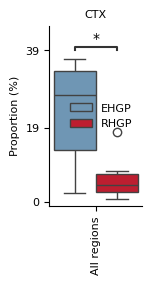

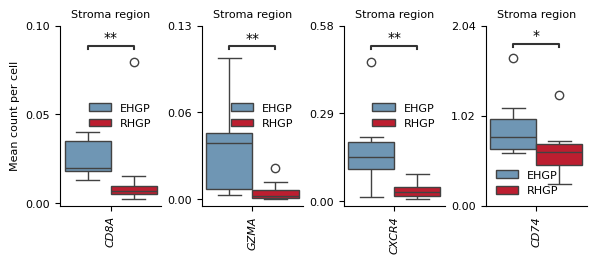

In [10]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
import numpy as np
from utils.plotting import custom_dotplot_raw, plot_gene_counts, plot_cluster_proportions_between_groups, BOXPLOT_HEIGHT, BOXPLOT_WIDTH


ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')


_, _, pval = plot_cluster_proportions_between_groups(
    ad, 
    cluster_key='Clusters with cytotoxic',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['Liver', 'Liver front', 'Portal tissue', 'Stroma', 'Tumor front', 'Tumor'],
    clusters_to_plot=['CTX'],
    save='svgs/cluster_proportions_ctx.svg',
)

ad_immune = ad[ad.obs['Clusters with cytotoxic'].isin(['CTX', 'MΦ']), :].copy()
ad_immune.obs['All regions'] = True
plot_cluster_proportions_between_groups(
    ad_immune, 
    cluster_key='Clusters with cytotoxic',
    group_key='Growth pattern',
    sample_key='Sample',
    patient_key='Patient',
    region_mask_keys=['All regions'],
    clusters_to_plot=['CTX'],
    save='svgs/cluster_proportions_ctx_all_immune_cells.svg'
)

genes = ['CD8A', 'GZMA', 'CXCR4', 'CD74']

fig, axs = plt.subplots(1, 4, figsize=(BOXPLOT_WIDTH(1) * len(genes) + 2, BOXPLOT_HEIGHT))

# Add padding between figures
plt.subplots_adjust(wspace=0.4)


for ax, gene in zip(axs, genes):
    plot_gene_counts(
        ad,
        group_key='Growth pattern',
        sample_key='Sample',
        patient_key='Patient',
        region_mask_keys=['Stroma'],
        genes=[gene],
        axes=np.array([ax]),
        save=f'svgs/gene_counts_ctx_{gene}_stroma.svg'
    )
    if ax != axs[0]:
        ax.set_ylabel(None)


## 2.6 Normalizing the data

Lower‑quality samples often have fewer reads per cell, which can skew raw gene‑count comparisons. To reduce this bias, we report a normalized version alongside the targeted (raw) counts:

For each sample we:
1. Compute a normalization factor: the average total gene count per cell within the region of interest.
2. Scale each gene: divide the gene’s average count in that region by the normalization factor.
3. Produce pseudo‑counts: multiply the normalized values by a constant equal to the average total gene count per cell across all samples and regions.

Finally, we group the pseudo-counts based on the samples growth pattern and compare using Mann-Whitney U-Test.

We compare this analysis with the non-normalized gene-count comparison to see if the normalization actually had any effect.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CRP_EHGP vs. CRP_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:1.996e-02 U_stat=1.600e+01
SAA1_EHGP vs. SAA1_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:6.233e-03 U_stat=1.100e+01
PLA2G2A_EHGP vs. PLA2G2A_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:2.797e-04 U_stat=0.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CRP_EHGP vs. CRP_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:7.963e-03 U_stat=1.200e+01
SAA1_EHGP vs. SAA1_RHGP: Mann-Whitney-Wilcoxon test two-sided, P_val:4.849e-03 U_stat=1.000e+01
PLA2G2A_EHGP vs. PLA2G2A_RHGP: Mann-Whitney-Wi

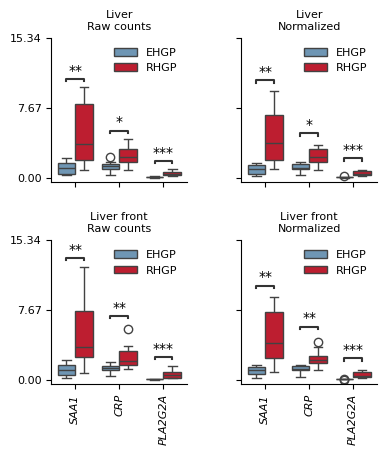

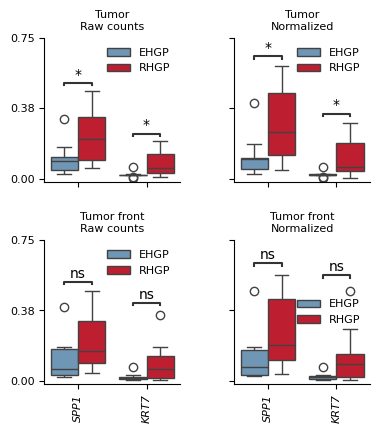

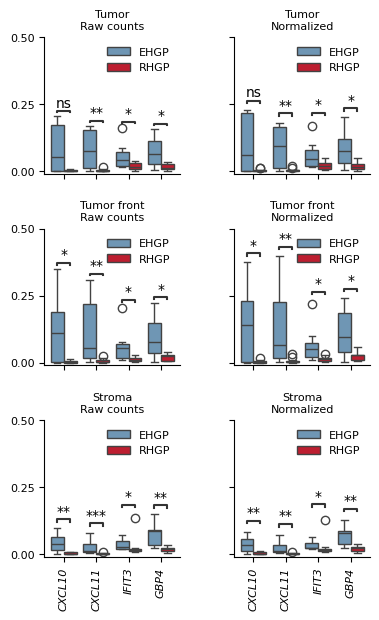

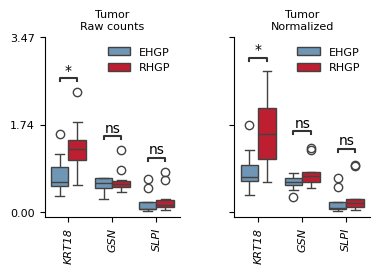

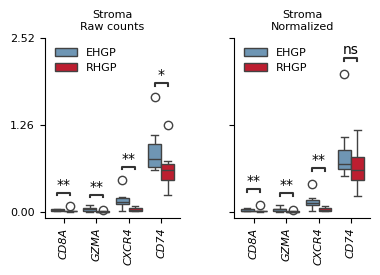

In [9]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import matplotlib.pyplot as plt
from utils.plotting import plot_gene_counts, BOXPLOT_HEIGHT, BOXPLOT_WIDTH, BOXPLOT_FONTSIZE

# Load anndata
ad = sc.read_h5ad('prepared_adata/prepared_cells_panel_2.h5ad')


## Compare gene counts between growth patterns in the liver and liver front regions, with and without normalization
def plot_comparison(ad, regions, genes, save=None):
    # Add padding between figures
    fig, axes = plt.subplots(len(regions), 2, figsize=(BOXPLOT_WIDTH(2) + 3, BOXPLOT_HEIGHT * len(regions)), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    if len(regions) == 1:
        axes = axes.reshape(1, -1)  # Ensure axes is 2D for consistent indexing

    plot_gene_counts(
        ad,
        group_key='Growth pattern',
        sample_key='Sample',
        patient_key='Patient',
        region_mask_keys=regions,
        genes=genes,
        plot_horizontal=False,
        axes=axes[:,0]
    )

    plot_gene_counts(
        ad,
        group_key='Growth pattern',
        sample_key='Sample',
        patient_key='Patient',
        region_mask_keys=regions,
        genes=genes,
        plot_horizontal=False,
        axes=axes[:,1],
        normalize=True
    )

    for row, region in enumerate(regions):
        for col, norm in enumerate(['Raw counts', 'Normalized']):
            axes[row, col].set_title(f'{region}\n{norm}', fontsize=BOXPLOT_FONTSIZE)

    if save is not None:
        plt.savefig(save, bbox_inches='tight')

# Compare normalization between liver and liver front regions for SAA1, CRP and PLA2G2A
# i.e., damaged hepatocyte-associated genes
plot_comparison(ad, ['Liver', 'Liver front'], ['SAA1', 'CRP', 'PLA2G2A'], save='svgs/compare_normalization_dhc.svg')

# Compare normalization between tumor and tumor front regions for SPP1 and KRT7
# i.e., bifunctional hepatocyte-cholagiocyte markers (assosciated with CC1 cluster)
plot_comparison(ad, ['Tumor', 'Tumor front'], ['SPP1', 'KRT7'], save='svgs/compare_normalization_cc.svg')

# Compare normalization between tumor, tumor front and stroma regions for CXCL10, CXCL11, IFIT3 and GBP4
# i.e., genes associated with the CAFγ and NCγ clusters 
plot_comparison(ad, ['Tumor', 'Tumor front', 'Stroma'], ['CXCL10', 'CXCL11', 'IFIT3', 'GBP4'], save='svgs/compare_normalization_ifn.svg')

# Compare normalization between tumor, tumor front and stroma regions for KRT18, GSN and SLPI
# i.e., genes associated with the neoplastic cluster, NC3, that was enriched on RHGP samples (tumor region).
plot_comparison(ad, ['Tumor'], ['KRT18', 'GSN', 'SLPI'], save='svgs/compare_normalization_nc3.svg')

# Compare normalization between stroma regions for CD8A, GZMA, CXCR4, and CD74, i.e., genes associated with 
# the cytotoxic T cell (CTX) cluster
plot_comparison(ad, ['Stroma'], ['CD8A', 'GZMA', 'CXCR4', 'CD74'], save='svgs/compare_normalization_ctx.svg')

## 2.7 Zonation analysis
In this section we analysis the distribution of markers across four different regions in encapsulating samples.

The regions are
1. The liver front: Covering the first 300 μm of hepatocyte liver rich tissue interfacing the capsule.
2. Capsule (liver side): the first 300 μm of capsule tissue facing towards the liver.
3. Capsule (tumor side): the first 300 μm of capsule tissue facing towards the tumor.
4. Tumor front: the first 300 μm of tumor tissue interfacing with the capsule.

The goal is to compute the count-per-area for different points (genes, cell types) and visualize the distribution using heatmaps.

In [58]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import scanpy as sc
from utils.regions import load_geojson, get_counts_per_area
from utils.format_data import to_points_df
image_folder = Path("data/images")

# Load anndata objects with reads and cells.
panel = 1
reads_ad = sc.read_h5ad(f"data/files/prepared_reads_panel_{panel}.h5ad")
cells_ad = sc.read_h5ad(f"prepared_adata/prepared_cells_panel_{panel}.h5ad")

# Convert to standardized dataframes with columns "x", "y", "Label", "Sample", "Growth pattern" 
# for downstream zonation analysis.
reads = to_points_df(reads_ad, panel=panel, label_col="Gene")
cells = to_points_df(cells_ad, panel=panel, label_col="Clusters")

# Keep only EHGP samples
reads = reads[reads["Growth pattern"] == "EHGP"].copy()
cells = cells[cells["Growth pattern"] == "EHGP"].copy()

# Stack reads and cells into one joint dataframe for downstream zonation analysis.
points_df = pd.concat([reads, cells], ignore_index=True)
points_df["Sample"] = points_df["Sample"].cat.remove_unused_categories()

# Create a function to check if a label corresponds to a cell type or not
cell_types = set(cells["Label"].cat.categories)
is_cell_fun = lambda s: s in cell_types

# Free memory; downstream code uses points_df plus mappings only.
reads_ad, cells_ad, reads, cells  = None, None, None, None

# Load regions as a GeoPandas
gdf = load_geojson(f"data/files/regions_panel_{panel}.json", panel=panel)

display(points_df.head())
display(gdf.head())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\axela\anaconda3\envs\iss_crclm\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,x,y,Label,collectionIndex,Sample,Growth pattern
0,202,331,DVL2,0,ENC-P01-S01,EHGP
1,402,353,DVL2,0,ENC-P01-S01,EHGP
2,155,338,MLXIPL,0,ENC-P01-S01,EHGP
3,494,58,CDH1,0,ENC-P01-S01,EHGP
4,508,159,MXD1,0,ENC-P01-S01,EHGP


,geometry,Subregion,Region,color,collectionIndex,Sample,Image Size
0,"MULTIPOLYGON (((10648 7488, 10640 7488, 10632 ...",Liver front,Liver front,#9467BD,0,ENC-P01-S01,"(18528, 12926)"
1,"MULTIPOLYGON (((12824 6976, 12824 6968, 12824 ...",Liver boundary,Liver boundary,#B700EB,0,ENC-P01-S01,"(18528, 12926)"
2,"MULTIPOLYGON (((16664 10656, 16656 10656, 1665...",Liver inside 0 μm - 50 μm,Liver inside,#1F77B4,0,ENC-P01-S01,"(18528, 12926)"
3,"MULTIPOLYGON (((16408 10816, 16400 10816, 1639...",Liver inside 50 μm - 100 μm,Liver inside,#3786BC,0,ENC-P01-S01,"(18528, 12926)"
4,"MULTIPOLYGON (((14216 10992, 14208 10992, 1420...",Liver inside 100 μm - 150 μm,Liver inside,#5095C4,0,ENC-P01-S01,"(18528, 12926)"


In [59]:
%load_ext autoreload
%autoreload 2
from utils.regions import get_counts_per_area

# Load counts per area
# Outputs dataframe with Sample and Gene as indices, and columns for each 
# region, with the count of reads per area in that region for that sample and gene
counts_per_area = get_counts_per_area(points_df, ['x', 'y'], 'Label', 'Sample', gdf)
# Normalize counts per area by total counts per area for each sample, 
# to get relative expression per area.
counts_per_area = counts_per_area.div(counts_per_area.sum(axis=1), axis=0)
# Merge samples from the same patient by averaging, to get one value per patient and gene.
# This to avoid inflating number of samples by treating samples from the same patient as independent, which they are not.
# Create a new column with (patient, gene) tuples
counts_per_area['Patient'] = counts_per_area.index.map(lambda s: s[0][:7]) # Assuming patient id is the first 7 characters of the sample name
# Average across samples from the same patient, to get one value per patient and gene.
## Group by patient and gene, and average the counts per area
counts_per_area = counts_per_area.groupby(['Patient', 'Label']).mean()
# Rename columns Liver outside and Tumor outside to Capsule (liver side) and Capsule (tumor side)
counts_per_area = counts_per_area.rename(
    columns = {
        'Liver outside': 'Capsule (liver side)', 
        'Tumor outside': 'Capsule (tumor side)', 
        'Liver inside' : 'Liver front', 
        'Tumor inside' : 'Tumor front'
    }
)

# Split counts per area into two dataframes, one for reads (transcripts)
# and one for cells
is_cell = counts_per_area.index.get_level_values('Label').map(is_cell_fun)
counts_per_area_reads = counts_per_area[~is_cell]
counts_per_area_cells = counts_per_area[is_cell]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing sample ENC-P01-S01
Processing sample ENC-P01-S02
Processing sample ENC-P02-S03
Processing sample ENC-P03-S04
Processing sample ENC-P04-S05
Processing sample ENC-P05-S06
Processing sample ENC-P06-S07
Processing sample ENC-P07-S08
Processing sample ENC-P08-S09
Processing sample ENC-P10-S11


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


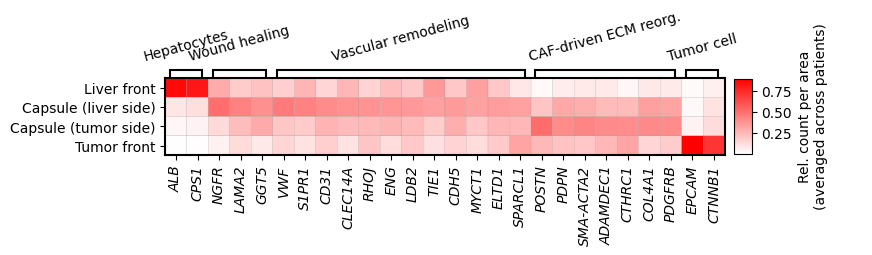

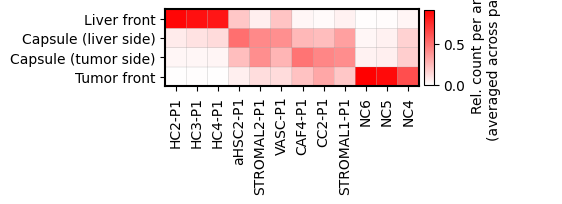

In [60]:
%load_ext autoreload
%autoreload 2
from utils.plotting import plot_counts_per_ehgp_region
import matplotlib.pyplot as plt
if panel == 1:
    gene_groups = {
        "Hepatocytes": ["ALB", "CPS1"],
        "Wound healing": ["NGFR", "LAMA2", "GGT5"],
        "Vascular remodeling": ["VWF", "S1PR1", "CD31", "CLEC14A", "RHOJ", "ENG","LDB2", "TIE1", "CDH5", "MYCT1", "ELTD1", "SPARCL1"],
        "CAF-driven ECM reorg.": ["POSTN", "PDPN", "SMA-ACTA2", "ADAMDEC1","CTHRC1", "COL4A1", "PDGFRB"],
        "Tumor cell": ["EPCAM", "CTNNB1"]
    }
else:
    gene_groups = {
        "Hepatocytes": ["ALB", "CPS1"],
        "Wound healing": ["PTGDS", "DPT", "CCDC80", "FBLN1", "CXCL12","LUM", "BGN", "ASPN"],
        "Cytotoxic T-cell": ["CXCR4", "GZMA", "CD8A"],
        "Immune signaling": ["CD69", "AIF1", "HLA-DRB1", "CD74"],
        "CAF-driven ECM reorg.": ["POSTN", "CTHRC1", "COL1A1", "MCAM", "MYH11"],
        "ECM degradation": ["MMP14", "TIMP3", "MMP11"],
        "Immunosuppression": ["INHBA", "FOXP3", "NOTCH3"],
        "Tumor cell": ["CDX2", "EPCAM"]
    }

plot_counts_per_ehgp_region(counts_per_area_reads, gene_groups, figsize=(9, 1), italic_labels=True, show_groups=True, save=f"svgs/ehgp_zonation_panel_{panel}.svg", cbar_max_height_in=0.75)
#plot_counts_per_ehgp_region(counts_per_area_reads, figsize=(12, 8), italic_labels=True, save=f"svgs/ehgp_zonation_all_genes_panel_{panel}.svg")
plot_counts_per_ehgp_region(counts_per_area_cells, figsize=(5, 1), italic_labels=False, show_groups=False, save=f"svgs/ehgp_zonation_clusters_panel_{panel}.svg", cbar_max_height_in=0.75)
plt.show()

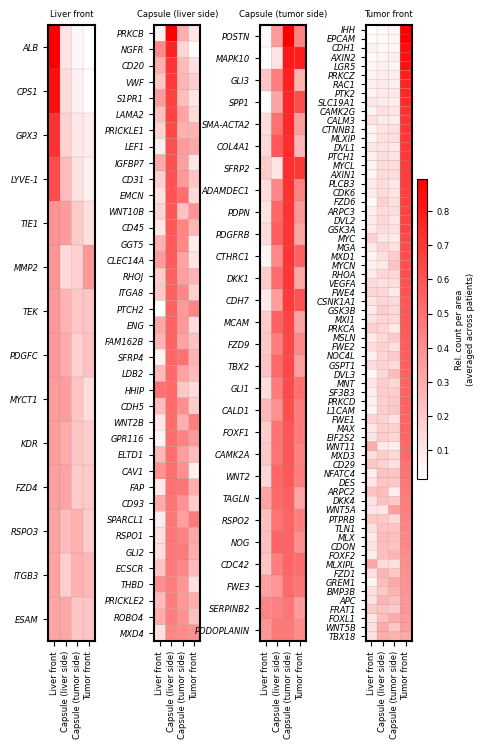

In [61]:
plot_counts_per_ehgp_region(counts_per_area_reads, figsize=(5, 8), split_by_group=True, italic_labels=True, swap_axes=True, fontsize=6, save=f"svgs/ehgp_zonation_panel_{panel}_split_by_group.svg")
plt.show()

## Plot DAPI, Regions, and Cluster Density
In this section we demonstrate how to plot one sample together with regions and a density map of some marker, for example the location of hepatocytes (HC1 labeled cells).

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\axela\AppData\Local\Temp\ipykernel_62808\2214207610.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


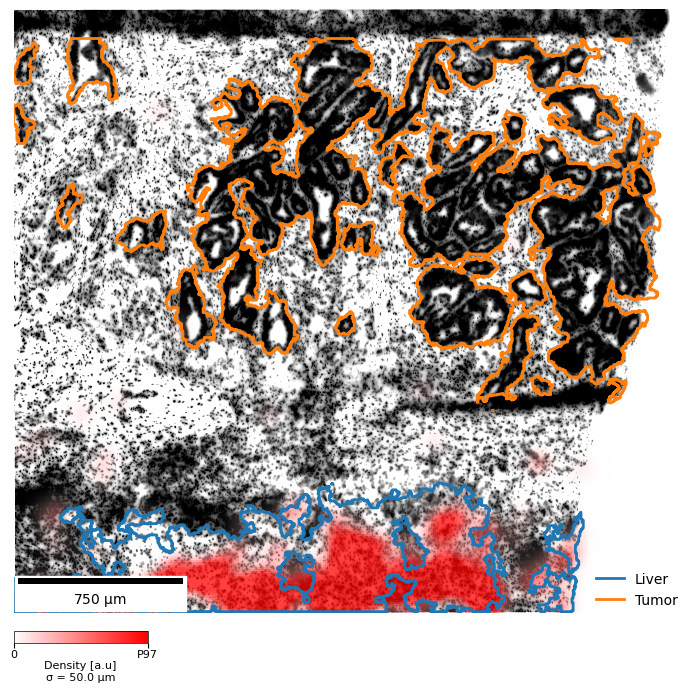

In [ ]:



%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import scanpy as sc

from utils.regions import load_geojson
from utils.slide_plotter import SlidePlotter

# Plot settings
panel = 2
sample = "ENC-P01-S01"
cluster = "HC1"
regions_to_show = ["Liver", "Tumor"]
sigma_um = 50.0
image_folder = Path("data/images")

# Load data
cells_ad = sc.read_h5ad(f"prepared_adata/prepared_cells_panel_{panel}.h5ad")
gdf = load_geojson(f"data/files/regions_panel_{panel}.json")

# Select one sample and one cluster
gdf_sample = gdf[gdf["Sample"] == sample]
xy = cells_ad[
    (cells_ad.obs["Sample"] == sample) & (cells_ad.obs["Clusters"] == cluster),
    :,
].obsm["spatial"]

# Keep only the regions we want to draw
gdf_region = gdf_sample[gdf_sample["Region"].isin(regions_to_show)]

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
plotter = SlidePlotter(ax)
plotter.plot_dapi(image_folder / f"iss_panel_{panel}_{sample}.tif")
plotter.plot_polygons(gdf_region, fill=False, linewidth=2)
plotter.plot_density(xy, sigma_um)
plotter.make_legend()
plt.tight_layout()